## Data Generation and Initial Setup

This cell generates synthetic 3D data for two classes using `numpy.random.multivariate_normal`. It then combines these samples into a single pandas DataFrame `df`, assigns target labels (0 or 1), and shuffles the data.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

## Display DataFrame Head

This cell displays the first 5 rows of the DataFrame `df`. This helps to quickly inspect the structure and content of the generated data.

In [2]:
df.shape

(40, 4)

## 3D Scatter Plot of Original Data

This cell uses `plotly.express` to create an interactive 3D scatter plot of the original data. It visualizes the three features (`feature1`, `feature2`, `feature3`) and colors the points based on the `target` variable, allowing for a visual inspection of class separability in 3D space.

In [3]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


## Display DataFrame Shape

This cell prints the dimensions (number of rows and columns) of the DataFrame `df`. This provides a quick overview of the data's size.

In [4]:
import plotly.express as px
#y_train_trf = y_train.astype(str)

fig = px.scatter_3d(df, x = df['feature1'], y = df['feature2'], z = df['feature3'], color = df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

## Step 1: Apply Standard Scaling

This cell performs standard scaling on the feature columns (`feature1`, `feature2`, `feature3`) of the DataFrame. Standard scaling transforms the data so that it has a mean of 0 and a standard deviation of 1. This is a crucial preprocessing step for PCA, as PCA is sensitive to the scale of the features.

In [5]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

## Step 2: Find Covariance Matrix

This cell calculates the covariance matrix of the scaled features. The covariance matrix is a square matrix that contains the variances of the individual features along the diagonal and the covariances between pairs of features in the off-diagonal elements. It is a fundamental component for PCA, as it quantifies the relationships between different features.

In [6]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)


Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


## Step 3: Finding Eigenvalues and Eigenvectors

This cell computes the eigenvalues and eigenvectors of the covariance matrix. Eigenvalues represent the magnitude of variance captured by each principal component, and eigenvectors represent the directions (principal components) in which the data varies the most. These are critical for determining the principal components.

In [7]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

## Display Eigenvalues

This cell simply displays the calculated eigenvalues. The magnitude of these values indicates the amount of variance explained by each corresponding eigenvector (principal component).

In [8]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

## Display Eigenvectors

This cell displays the calculated eigenvectors. Each column of this matrix is an eigenvector, representing a principal component. These vectors define the new coordinate system to which the data will be projected.

In [9]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

## 3D Visualization of Eigenvectors

This cell visualizes the original 3D data points along with their mean and the eigenvectors. The custom `Arrow3D` class is used to draw 3D arrows representing the eigenvectors originating from the data's mean. This helps to understand the directions of maximum variance in the original feature space.

Populating the interactive namespace from numpy and matplotlib


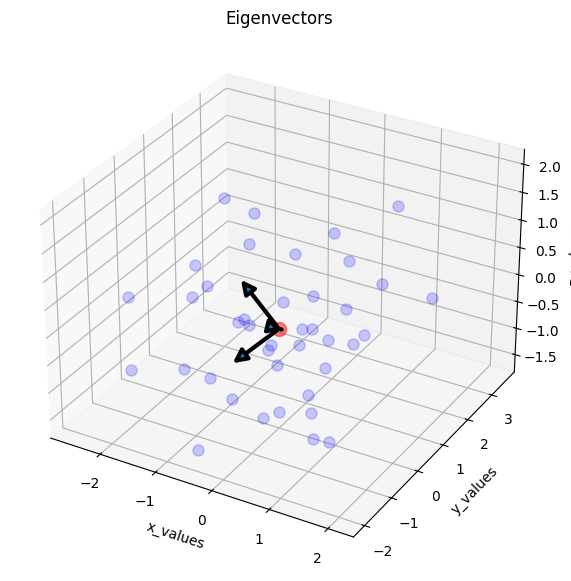

In [10]:

%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        # Access the projection matrix from the axes object
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self, renderer=None):
        # Calculate the projected coordinates of the arrow's start and end points
        x1, y1, z1 = proj3d.proj_transform(self._verts3d[0][0], self._verts3d[1][0], self._verts3d[2][0], self.axes.M)
        x2, y2, z2 = proj3d.proj_transform(self._verts3d[0][1], self._verts3d[1][1], self._verts3d[2][1], self.axes.M)
        # Return the average z-coordinate for depth sorting
        return (z1 + z2) / 2

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

## Select Principal Components

This cell selects the first two principal components (eigenvectors with the largest eigenvalues). These principal components will be used to transform the 3D data into a 2D space, effectively reducing dimensionality while retaining most of the variance.

In [11]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

## Project Data onto Selected Principal Components

This cell projects the original 3D scaled data onto the selected 2 principal components. The dot product of the feature matrix and the transpose of the principal components matrix results in the transformed data, now in a 2D space. A new DataFrame `new_df` is created to store these 2D principal components (PC1, PC2) along with the original target variable.

In [12]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()


,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


## 2D Scatter Plot of Transformed Data

This cell generates a 2D scatter plot using the `plotly.express` library. It visualizes the data after it has been projected onto the first two principal components (`PC1` and `PC2`). The points are colored according to their `target` variable, allowing for a clear view of how well the classes are separated in the reduced-dimensional space. This plot is essential for assessing the effectiveness of PCA in separating the classes.

In [13]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()